In [30]:
import matplotlib.pyplot as plt
import csv
import json
import numpy as np
def get_APD(voltage, dt,APD_percentage = 0.1): # lib is 2D array, each row is a time series of one pixel
    def linear_interpolation(y0,y1,x0,x1,x):
        
        return (y0 * (x1-x) + y1 * (x-x0)) / (x1-x0)
    APD_percentage = APD_percentage * (max(voltage) - min(voltage)) + min(voltage)
    APD_start_point = None
    APD_end_point = None
    start_apd = False
    APD_value = 0
    APD_start_error = -100
    APD_end_error = -100
    for j in range(len(voltage)):


        if start_apd == False and voltage[j] > APD_percentage:
            start_apd = True
            if j == 0:
                APD_start_error = 0
            else:
                APD_start_error = linear_interpolation(1,0,voltage[j],voltage[j-1],APD_percentage)
                APD_start_error = 1 - APD_start_error
            APD_start_point = j - 1 + APD_start_error
        if start_apd == True and voltage[j] <= APD_percentage: 
            start_apd = False
            APD_end_error = linear_interpolation(0,-1,voltage[j],voltage[j-1],APD_percentage)
            APD_end_point = j + APD_end_error
            APD_value += (APD_start_error + APD_end_error) * dt                
            APD_start_error = -100
            APD_end_error = -100
        if start_apd == True:
            APD_value += dt
    return APD_value,[APD_start_point,APD_end_point]
def get_dvdt_max_and_plateau_duration(voltage,dt):
    dvdt_max = -1e6
    dvdt_plateau_lower_bound = -0.350
    plateau_duration = 0
    plateau_end_idx = None
    for j in range(1,len(voltage)):
        dvdt = (voltage[j] - voltage[j-1]) / dt
        plateau_duration += dt
        if dvdt > dvdt_max:
            dvdt_max = dvdt
        if dvdt < 0 and j > 100 and dvdt < dvdt_plateau_lower_bound:
            plateau_end_idx = j
            return dvdt_max, plateau_duration, plateau_end_idx
    return dvdt_max, plateau_duration, plateau_end_idx

def get_AP(voltage_signal):
    APs = []
    starting_indexes = []
    current_AP = []
    in_AP = False
    for i in range(1, len(voltage_signal)):
        dv_dt = voltage_signal[i] - voltage_signal[i-1]
        if not in_AP:
            if dv_dt > 0.005 and voltage_signal[i-1] < 0:
                in_AP = True
                current_AP = [voltage_signal[i-1], voltage_signal[i]]
                current_AP_start_idx = i - 1
                starting_indexes.append(current_AP_start_idx)
        else:
            current_AP.append(voltage_signal[i])
            if i + 1 < len(voltage_signal):
                next_dv_dt = voltage_signal[i+1] - voltage_signal[i]
                if next_dv_dt > 0.005 and voltage_signal[i] < 0 and len(current_AP) > 3000:
                    in_AP = False
                    APs.append(current_AP)
                    current_AP = []    
    return APs, starting_indexes

In [ ]:
# read csv
para = 12
nbins = 2500
period = 500
csv_file = rf".\populationCell_period_{period}_measureTime_40000_C_Na_C_K1_C_to_C_Kr_C_Ks_pKNa_C_CaL_kNaCa_C_pK_C_pCa_C_bNa_C_bCa_300.csv"
step = None
voltage = {}
prev_key = float(-1)
with open(csv_file, 'r') as file:
    reader = csv.reader(file, delimiter=',')
    cur_v = []
    for row in reader:
        if len(row) == 1:
            key = float(row[0].split('_')[1].replace('ID',''))
            if prev_key != -1 and prev_key < 300:
                voltage[prev_key] = cur_v
            prev_key = key
            continue
        cur_v = [float(v) for v in row if v]
    #voltage[prev_key] = cur_v
# APD = get_APD(voltage, dt=step, APD_percentage=0.3)
# read a json file.
with open (f"./2D-TNNP - Na - pace/population_params_{para}_N_{nbins}.json") as file:
    parameters = json.load(file)
parameters = {int(k['id']): {item[0]: round(item[1],2) for item in k.items() if item[0] != 'id'} for k in parameters}



In [39]:
APD_90_lst = []
plateau_duration_lst = []
dv_dt_max_lst = []
v_peak_lst = []
RMP_lst = []
dome_peak_lst = []
for key in sorted(voltage.keys()):
    APs, starting_indexes = get_AP(voltage[key])
    
    last_AP = APs[-1]
    
    APD_90, APD_points = get_APD(last_AP, dt=0.2, APD_percentage=0.1) # dt=0.2 ms
    dvdt_max, plateau_duration, plateau_end_idx = get_dvdt_max_and_plateau_duration(last_AP, dt=0.2) # dt=0.2 ms
    v_peak = max(last_AP)
    RMP = min(last_AP)
    dome_peak = max(last_AP[np.argmax(last_AP)+10:])
    if not APD_90:
        print(f"Key {key} has no APD_90")
    APD_90_lst.append(APD_90)
    plateau_duration_lst.append(plateau_duration)
    dv_dt_max_lst.append(dvdt_max)
    v_peak_lst.append(v_peak)
    RMP_lst.append(RMP)
    dome_peak_lst.append(dome_peak)


{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 63, 64, 65, 66, 67, 69, 70, 71, 72, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231

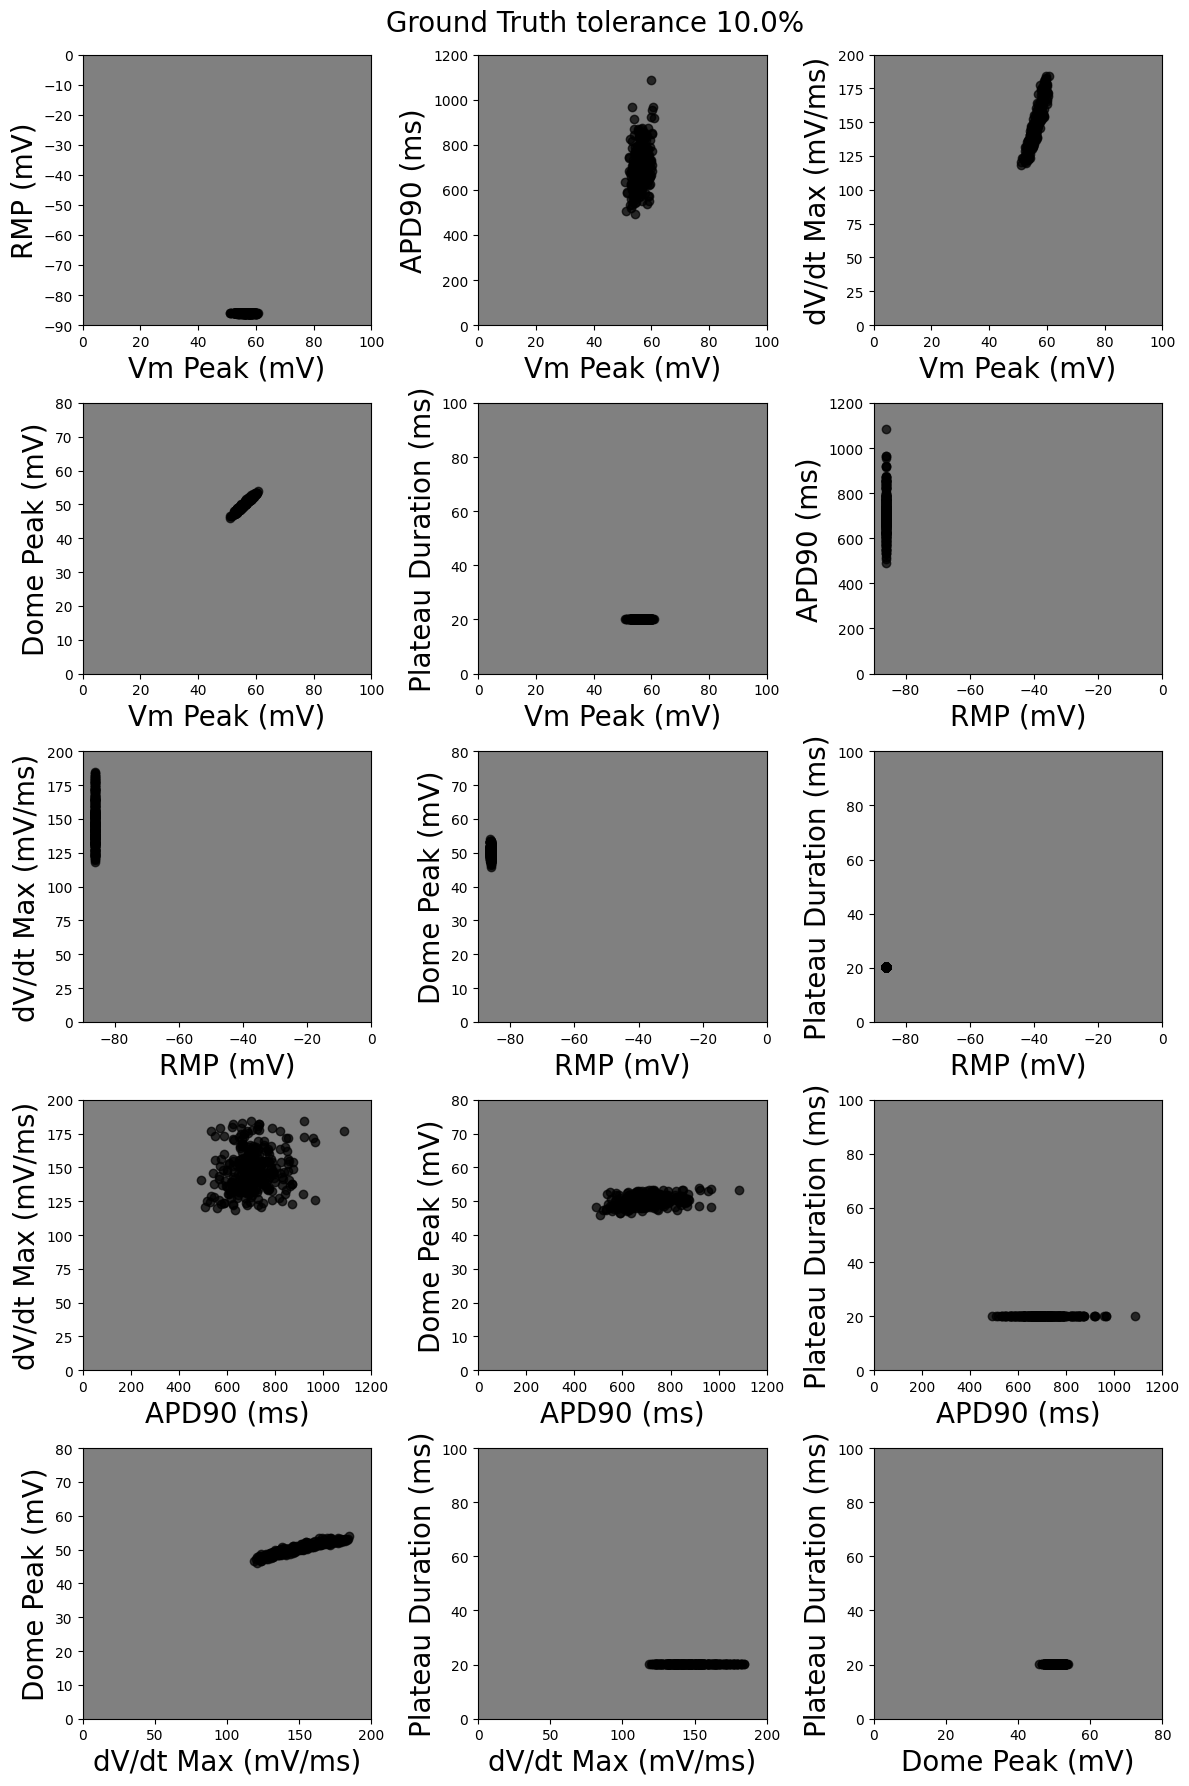

In [ ]:
def plot_2d_biomarkers(ax,m1,m2,tolerance,m1_name,m2_name,m1_range=None,m2_range=None):
    ax.scatter(m1[1:], m2[1:], alpha=0.7,color = 'black')
    # also plot ground truth m1[0], m2[0] with 5% error tolerance as vertical and horizontal white lines
    ax.axvline(x=m1[0]*(1+tolerance), color='w', linestyle='--', label='Ground Truth +5%')
    ax.axvline(x=m1[0]*(1-tolerance), color='w', linestyle='--', label='Ground Truth -5%')
    ax.axhline(y=m2[0]*(1+tolerance), color='w', linestyle='--', label='Ground Truth +5%')
    ax.axhline(y=m2[0]*(1-tolerance), color='w', linestyle='--', label='Ground Truth -5%')
    # make the background grey
    ax.set_facecolor('grey')
    ax.set_xlabel(m1_name, fontsize=20)
    ax.set_ylabel(m2_name, fontsize=20)
    ax.margins(0.05)
    
    # set xy range
    if m1_range:
        ax.set_xlim(m1_range)
    if m2_range:
        ax.set_ylim(m2_range)
    
    # besides plot, also filter the point ID within the tolerance and return them
    within_tolerance_ids = [i for i in range(1, len(m1)) if (m1[0]*(1-tolerance) <= m1[i] <= m1[0]*(1+tolerance)) and (m2[0]*(1-tolerance) <= m2[i] <= m2[0]*(1+tolerance))]
    return within_tolerance_ids
    
    
biomarkers = {
    'APD90 (ms)': APD_90_lst,
    'Plateau Duration (ms)': plateau_duration_lst,
    'dV/dt Max (mV/ms)': dv_dt_max_lst,
    'Vm Peak (mV)': v_peak_lst,
    'RMP (mV)': RMP_lst,
    'Dome Peak (mV)': dome_peak_lst,
}

biomarkers_range = {
    'APD90 (ms)': (0, 1200),
    'Plateau Duration (ms)': (0, 100),
    'dV/dt Max (mV/ms)': (0, 200),
    'Vm Peak (mV)': (0, 100),
    'RMP (mV)': (-90, 0),
    'Dome Peak (mV)': (0, 80),
}

plot_pairs = [
    # Row 1
    ('Vm Peak (mV)', 'RMP (mV)'),
    ('Vm Peak (mV)', 'APD90 (ms)'),
    ('Vm Peak (mV)', 'dV/dt Max (mV/ms)'),
    # Row 2
    ('Vm Peak (mV)', 'Dome Peak (mV)'),
    ('Vm Peak (mV)', 'Plateau Duration (ms)'),
    ('RMP (mV)', 'APD90 (ms)'),
    # Row 3
    ('RMP (mV)', 'dV/dt Max (mV/ms)'),
    ('RMP (mV)', 'Dome Peak (mV)'),
    ('RMP (mV)', 'Plateau Duration (ms)'),
    # Row 4
    ('APD90 (ms)', 'dV/dt Max (mV/ms)'),
    ('APD90 (ms)', 'Dome Peak (mV)'),
    ('APD90 (ms)', 'Plateau Duration (ms)'),
    # Row 5
    ('dV/dt Max (mV/ms)', 'Dome Peak (mV)'),
    ('dV/dt Max (mV/ms)', 'Plateau Duration (ms)'),
    ('Dome Peak (mV)', 'Plateau Duration (ms)'),
]

tolerance = 0.1
within_tolerance_ids_all = set()

# Create the figure and the 5x3 grid of subplots
fig, axes = plt.subplots(5, 3, figsize=(12, 18))
fig.tight_layout(pad=3.0) # Add padding between subplots

for i, pair in enumerate(plot_pairs):
    r = i // 3
    c = i % 3
    
    m1_name, m2_name = pair
    m1_data = biomarkers[m1_name]
    m2_data = biomarkers[m2_name]
    
    within_tolerance_ids = plot_2d_biomarkers(axes[r, c], m1_data, m2_data, tolerance, m1_name, m2_name, biomarkers_range[m1_name], biomarkers_range[m2_name])
    within_tolerance_ids_all.update(within_tolerance_ids)
print(within_tolerance_ids_all)
plt.suptitle(f'Ground Truth tolerance {tolerance*100}%', fontsize=20,y=0.99)
plt.tight_layout()
plt.savefig("TNNP_cell_para_Variation_biomarkers_2D.png", dpi=300)
plt.show()

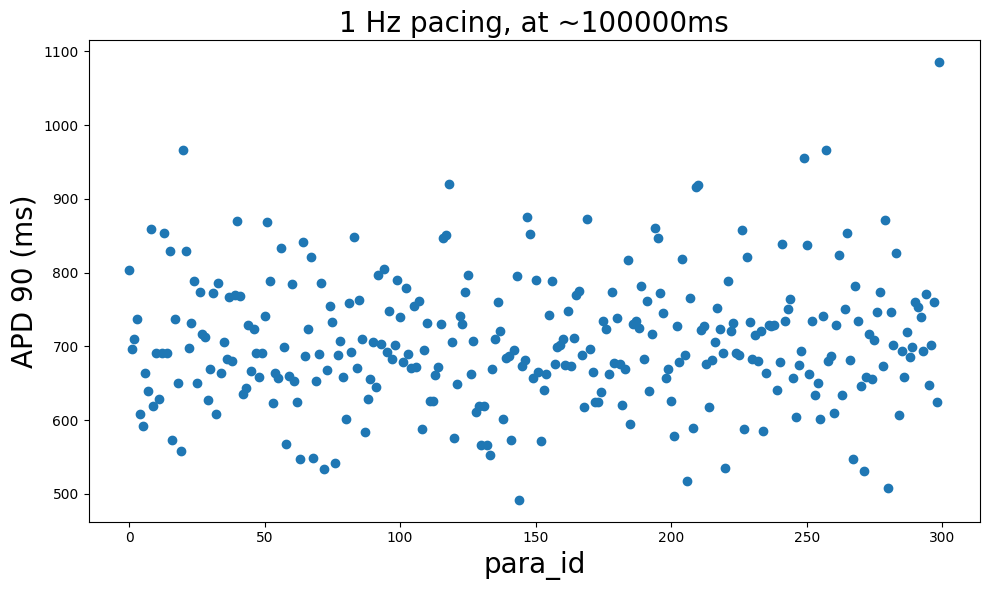

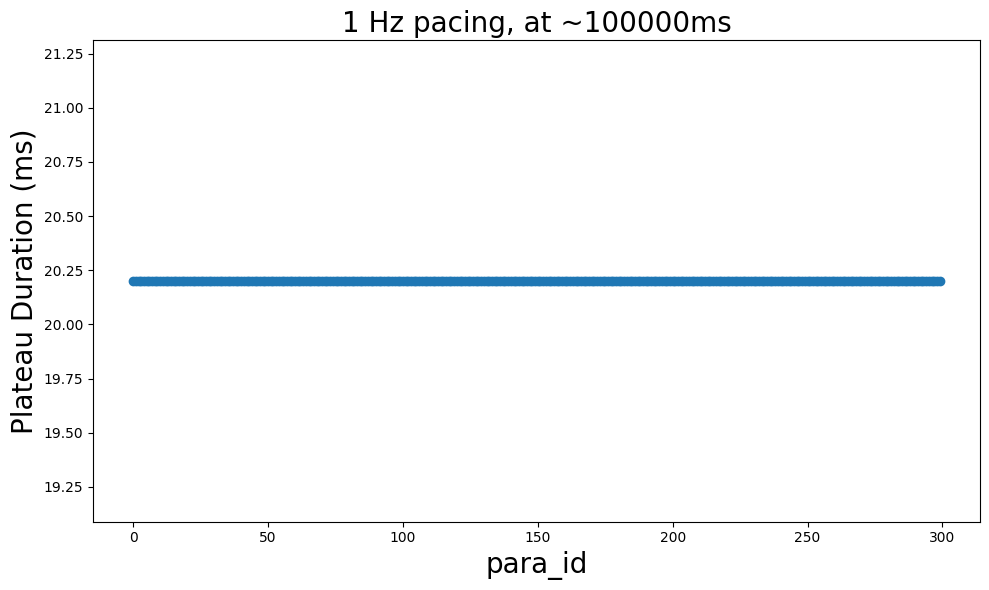

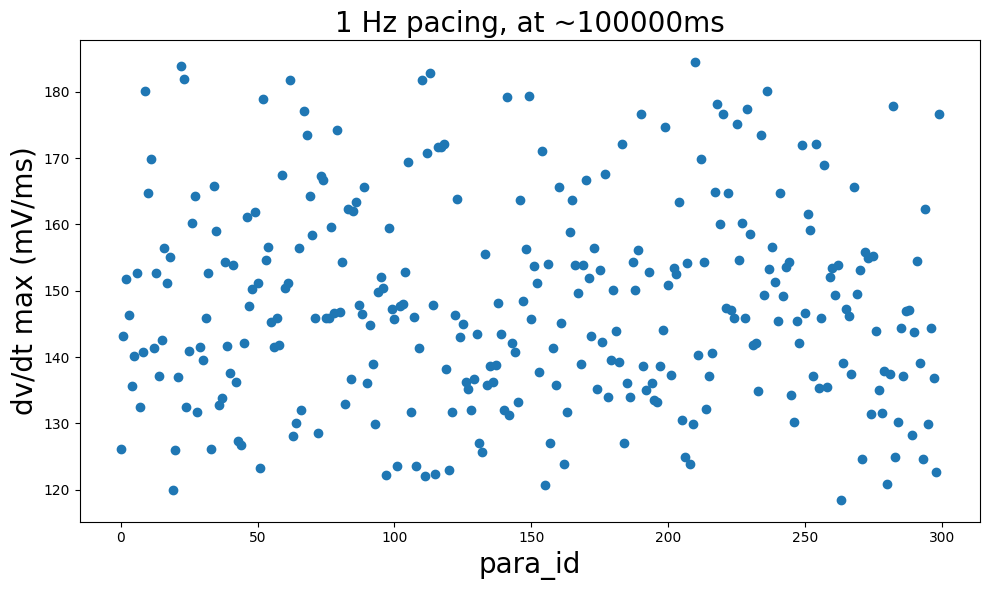

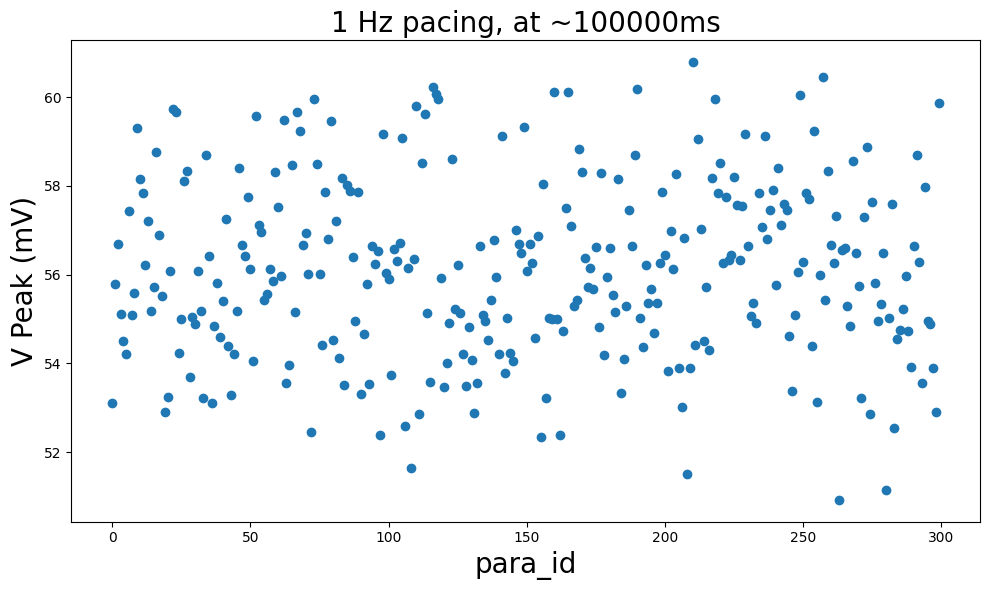

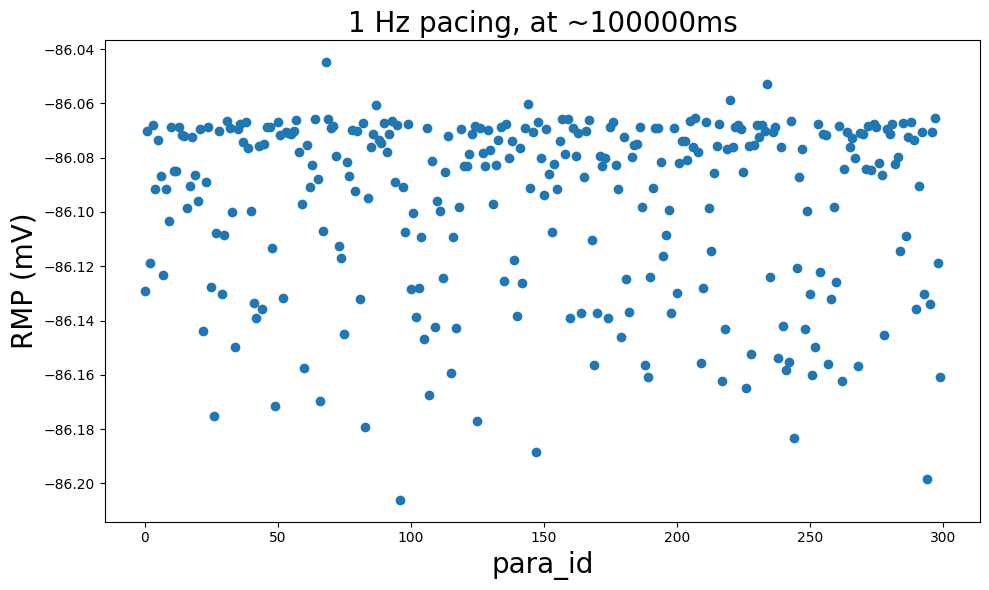

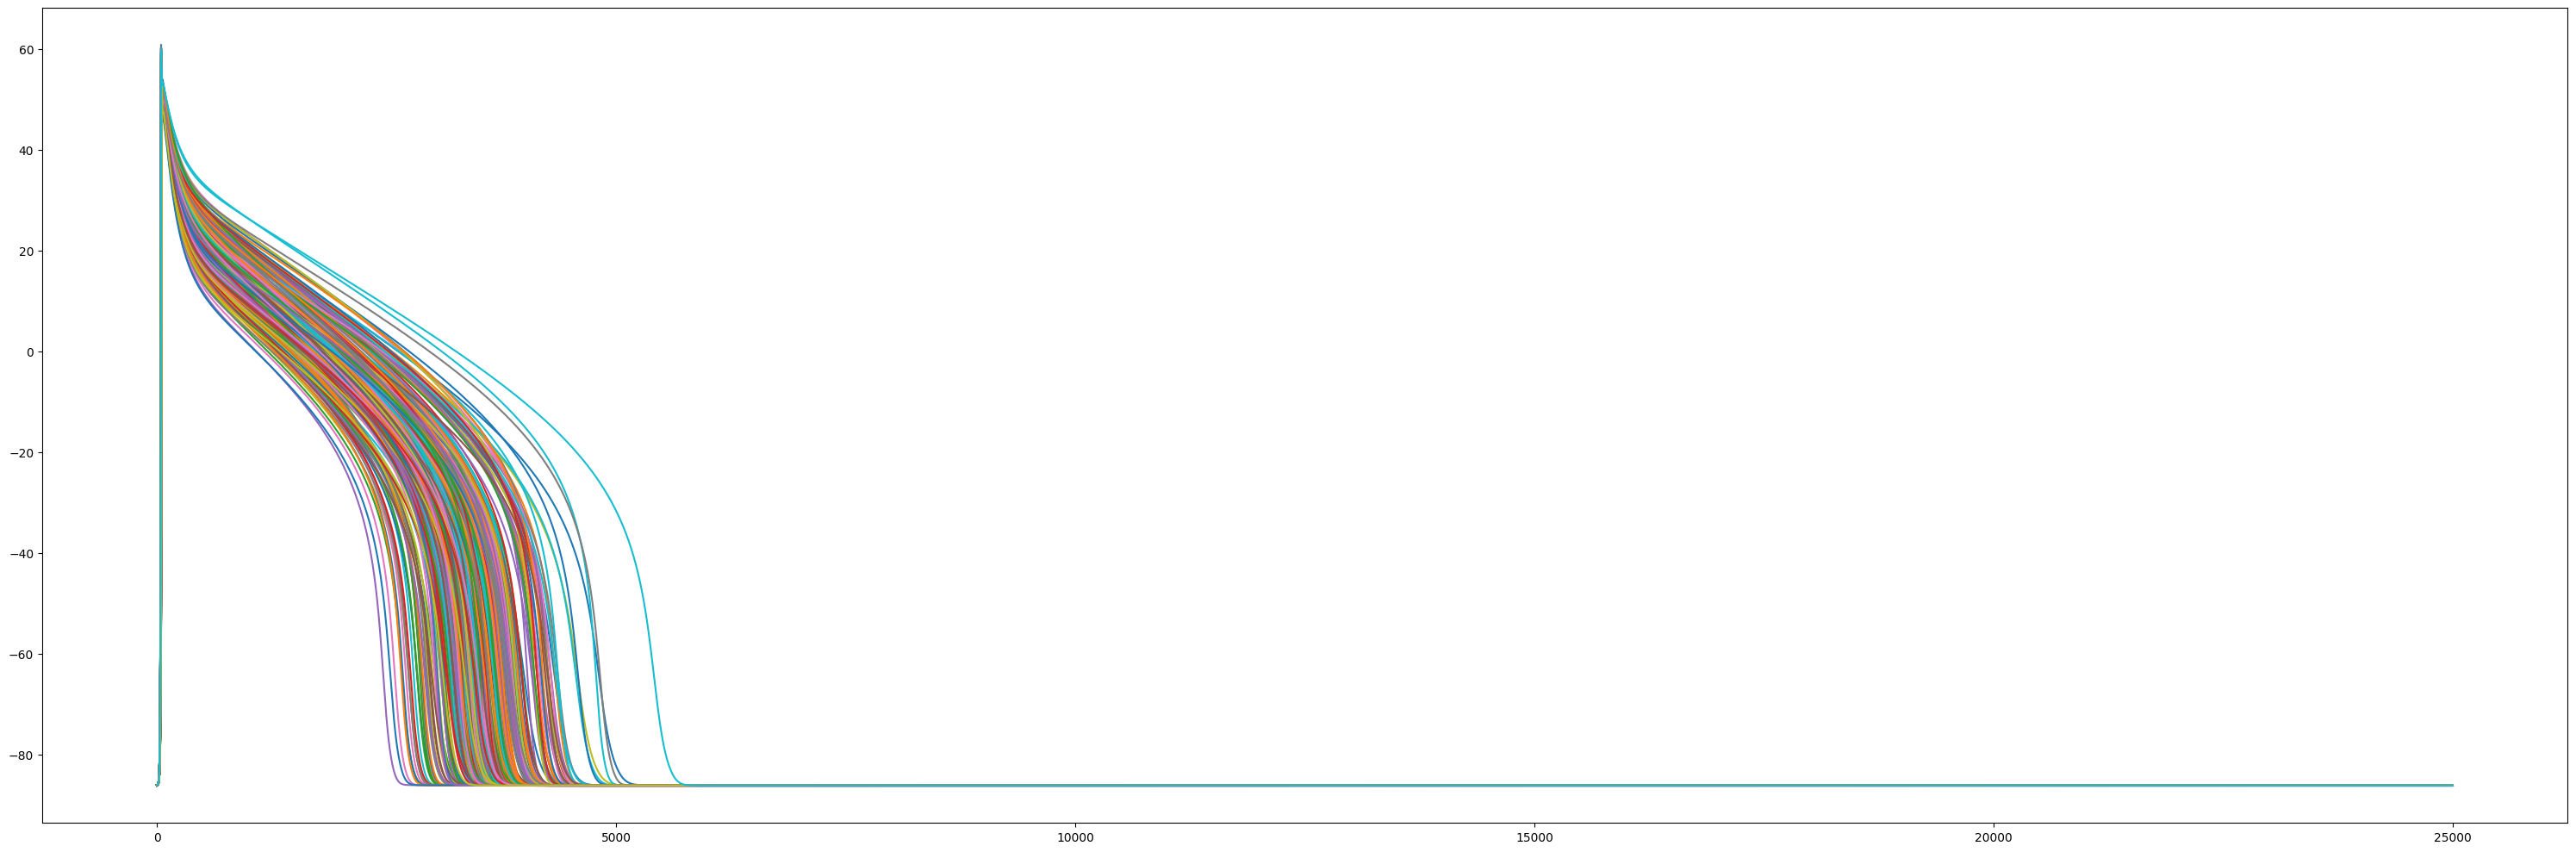

In [42]:
# plot APD_90 scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), APD_90_lst)
plt.ylabel("APD 90 (ms)",size=20)
plt.xlabel("para_id",size=20)
plt.title("1 Hz pacing, at ~100000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_cell_para_APD90.png", dpi=300)

# plot plateau_duration scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), plateau_duration_lst)
plt.ylabel("Plateau Duration (ms)",size=20)
plt.xlabel("para_id",size=20)
plt.title("1 Hz pacing, at ~100000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_cell_para_PlateauDuration.png", dpi=300)

# plot dv_dt_max scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), dv_dt_max_lst)
plt.ylabel("dv/dt max (mV/ms)",size=20)
plt.xlabel("para_id",size=20)
plt.title("1 Hz pacing, at ~100000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_cell_para_dv_dt_max.png", dpi=300)

# plot v_peak scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), v_peak_lst)
plt.ylabel("V Peak (mV)",size=20)
plt.xlabel("para_id",size=20)
plt.title("1 Hz pacing, at ~100000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_cell_para_VPeak.png", dpi=300)

# plot RMP scatter plot vs Na
plt.figure(figsize=(10,6))
plt.scatter(sorted(voltage.keys()), RMP_lst)
plt.ylabel("RMP (mV)",size=20)
plt.xlabel("para_id",size=20)
plt.title("1 Hz pacing, at ~100000ms",size=20)
plt.tight_layout()
plt.savefig("TNNP_cell_para_RMP.png", dpi=300)

# plot all APs in one plot and give gradient color for  Na value
plt.figure(figsize=(30,10))
for key in sorted(voltage.keys()):
    APs, starting_indexes = get_AP(voltage[key])
    last_AP = APs[-1]
    plt.plot(last_AP, label=f"Na={key:.1f}")
plt.tight_layout()
plt.savefig("TNNP_cell_para_AllAPs.png", dpi=300)


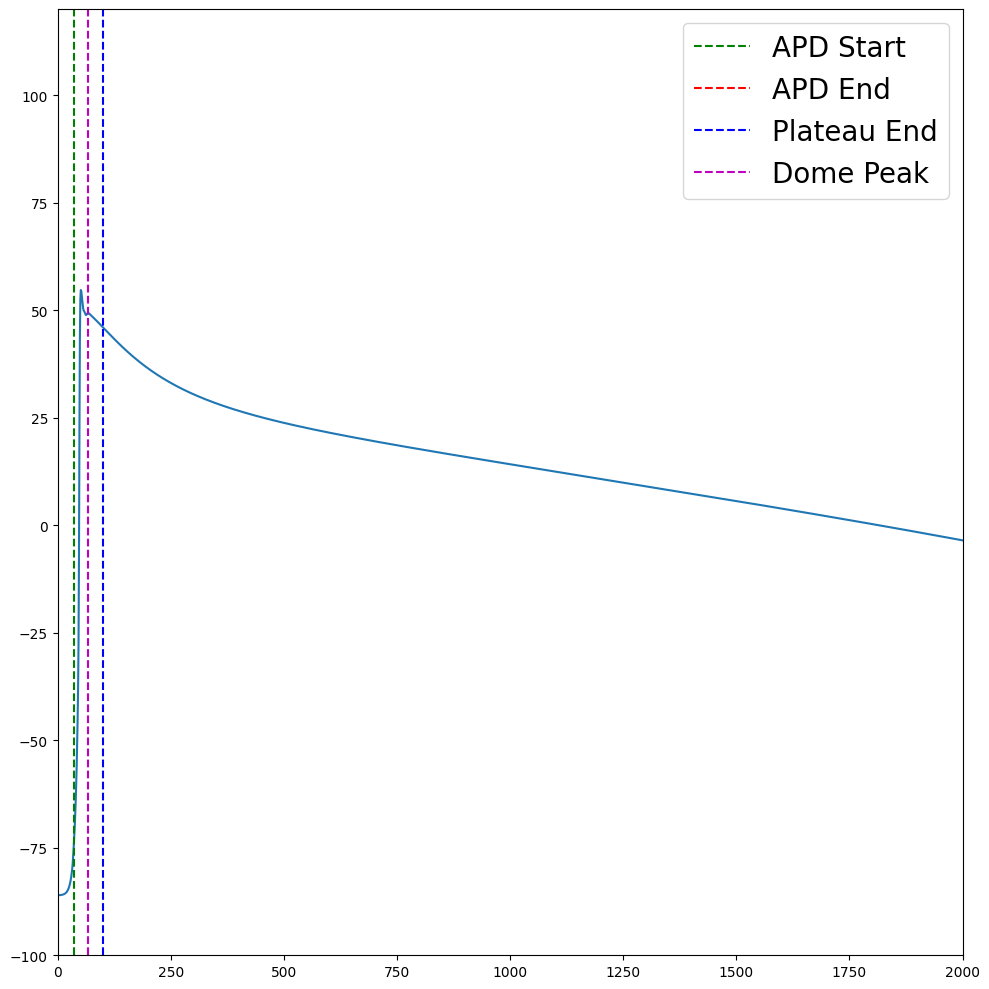

In [27]:
plt.figure(figsize=(10,10))
plt.ylim(-100,120)
plt.xlim(0,2000)
APs, starting_indexes = get_AP(voltage[91])
last_AP = APs[-1]
plt.plot(last_AP)
dvdt_max,plateau_duration, plateau_end_idx = get_dvdt_max_and_plateau_duration(last_AP, dt=0.2) # dt=0.2 ms\
APD, APD_boundary = get_APD(last_AP, dt=0.2, APD_percentage=0.1)
# plot apd boundary, plateau_end as vertical line
plt.axvline(x=APD_boundary[0], color='g', linestyle='--', label='APD Start')
plt.axvline(x=APD_boundary[1], color='r', linestyle='--', label='APD End')
plt.axvline(x=plateau_end_idx, color='b', linestyle='--', label='Plateau End')
first_max_idx = np.argmax(last_AP)
second_max_idx = np.argmax(last_AP[first_max_idx+10:]) + first_max_idx + 10

plt.axvline(x=second_max_idx, color='m', linestyle='--', label='Dome Peak')
plt.legend(fontsize=20)
plt.tight_layout()
plt.savefig("TNNP_cell_Na_AP.png", dpi=300)

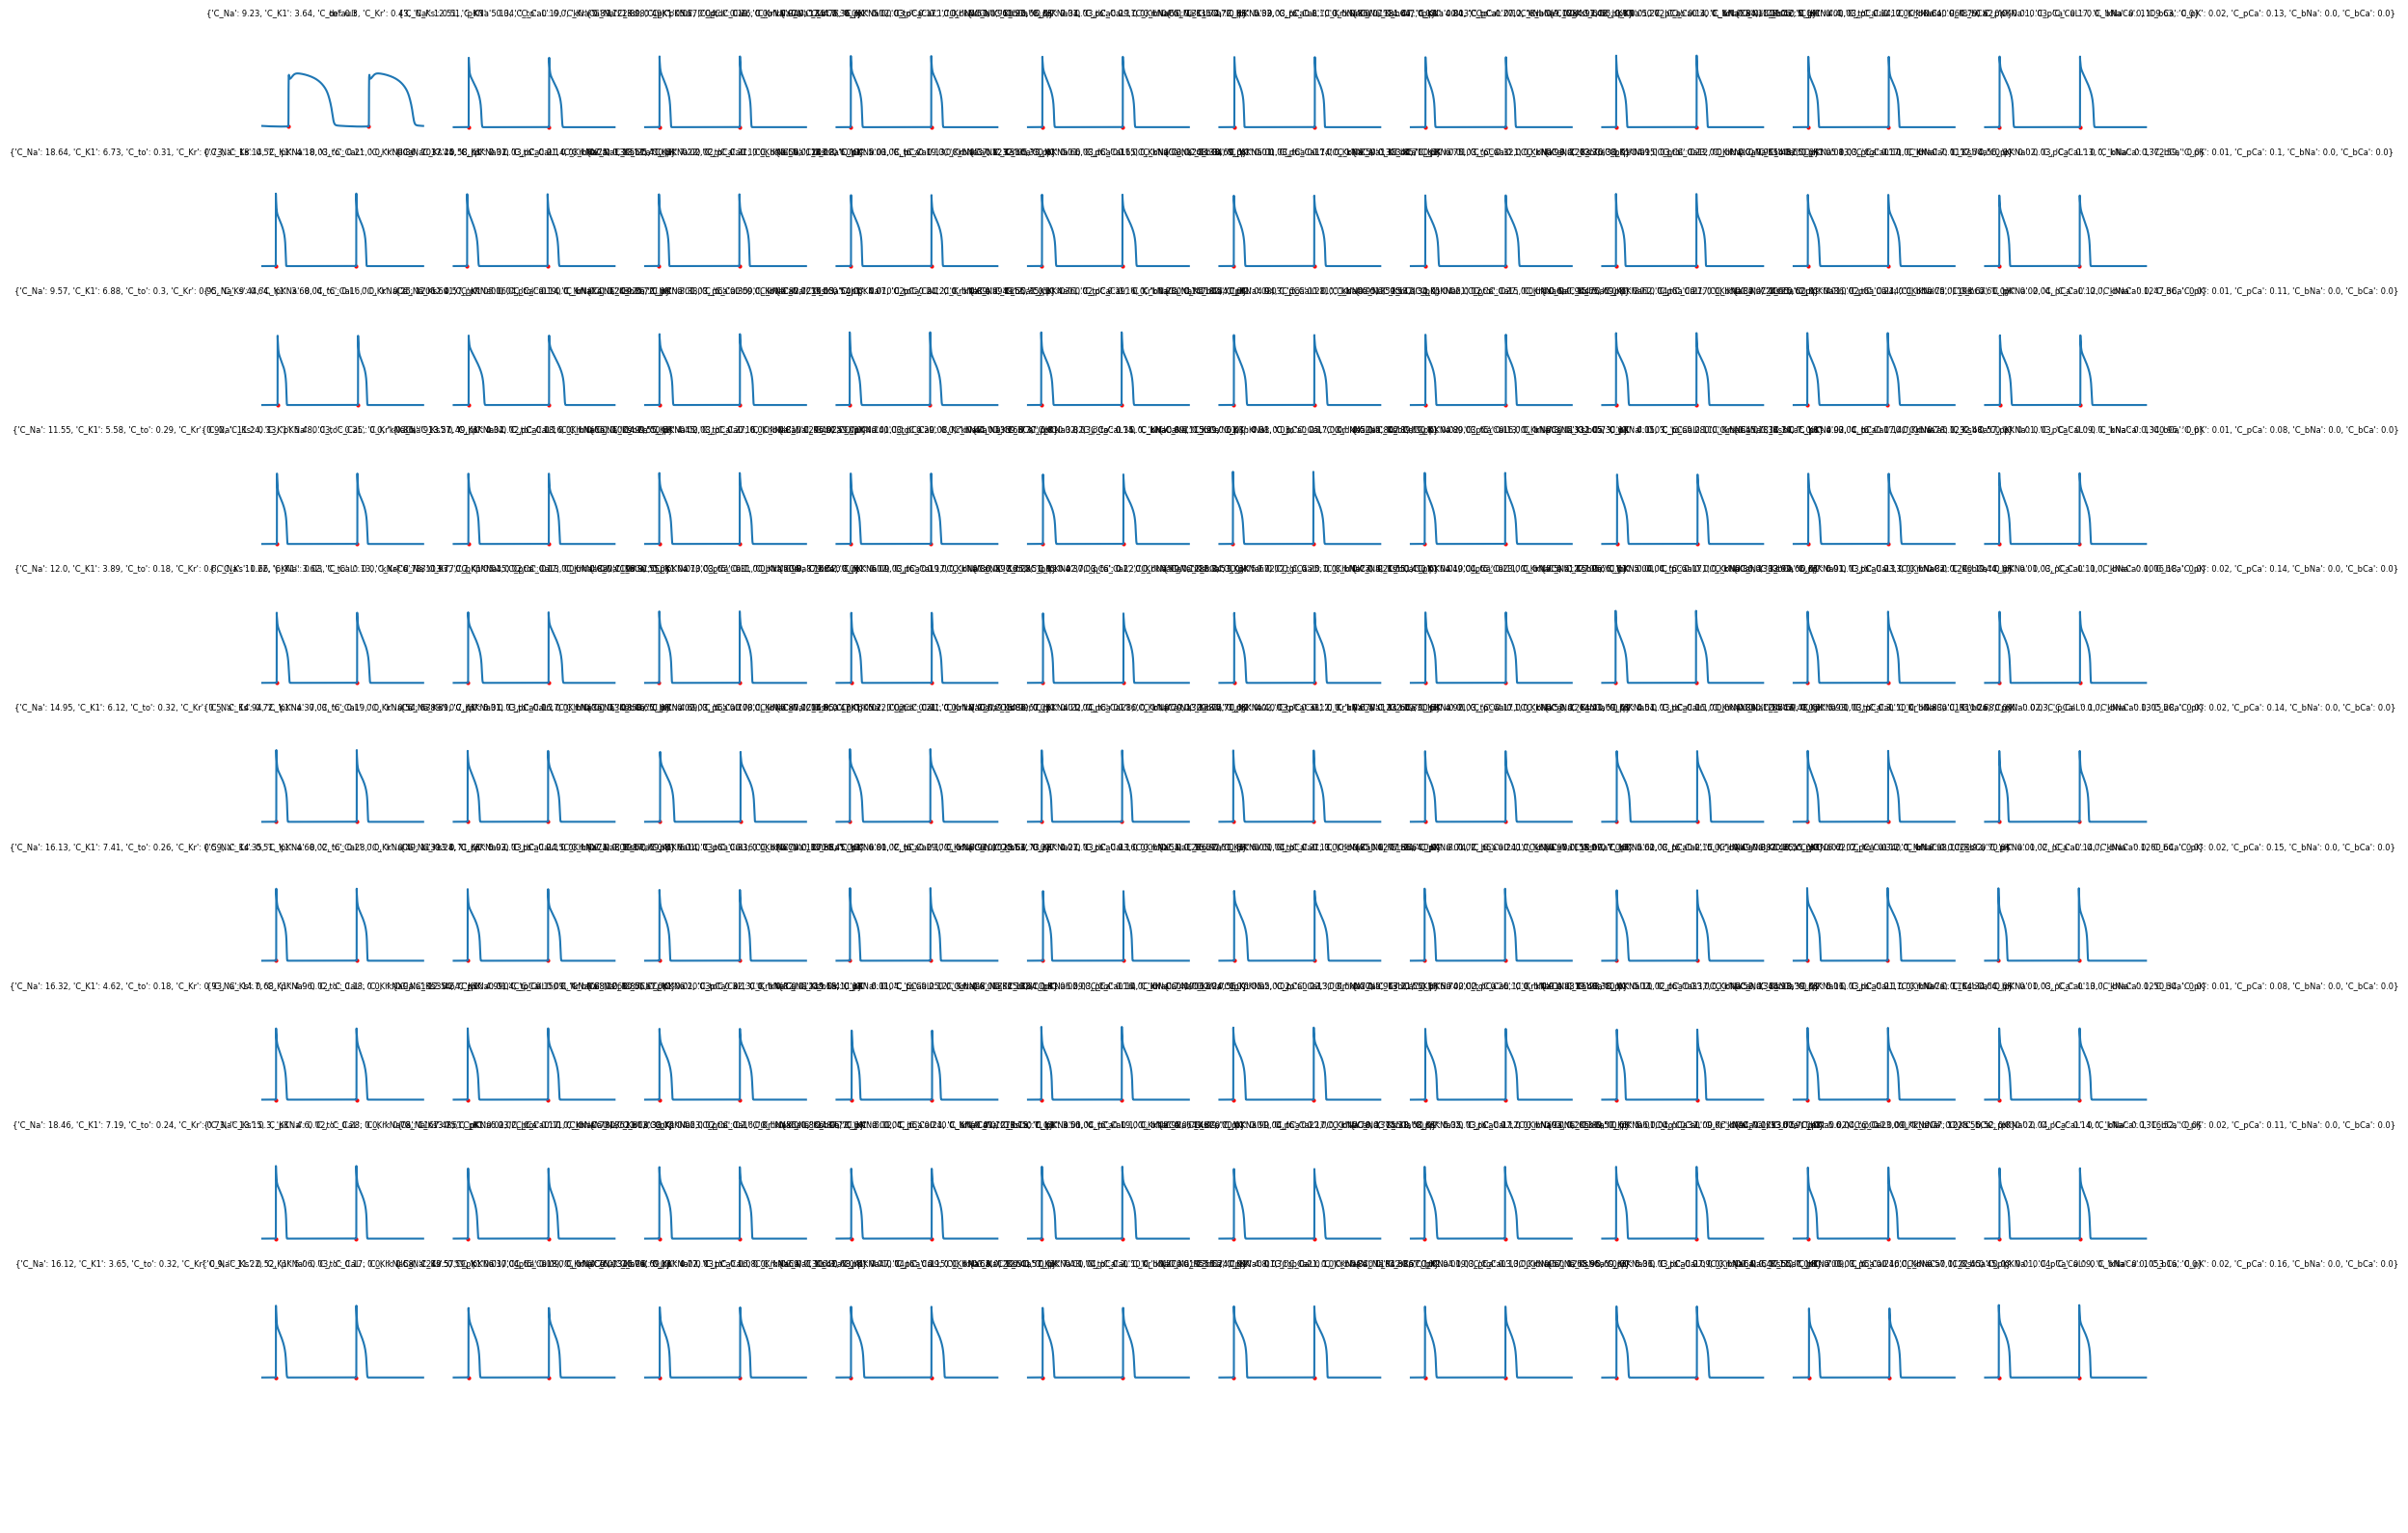

In [16]:
# 1. Create an 8x10 grid (100 slots for 100 plots)
fig, axs = plt.subplots(11, 10, figsize=(20, 16))

# Start the 'Na' key value
key_Na = -1
max_key = 100
# 2. Flatten the grid to a single list for easy looping
# Enumerate over the 80 subplot axes in the flattened array
for i, ax in enumerate(axs.flat):
    
    # We only want to plot in the first 75 subplots
    if i < max_key:
        # Check if the data for the current key exists
        if key_Na in voltage:
            APs, starting_indexes = get_AP(voltage[key_Na])
            for start_idx in starting_indexes:
                ax.plot(start_idx, voltage[key_Na][start_idx], 'ro', markersize=2) # size 10 red dot
            # --- 🎯 THE FIX ---
            # Use ax.plot() directly on the subplot axis object to draw a line graph.
            ax.plot(voltage[key_Na], color='C0')
            ax.set_ylim(-100,120)
            # Set the title with the current Na value
            if key_Na == -1:
                ax.set_title(f"default", fontsize=6)
            else:
                ax.set_title(f"{parameters[key_Na]}", fontsize=6)
            key_Na += 1
            # Optional: Customize axes for line plots
            ax.set_xticks([]) # Remove x-ticks
            ax.set_yticks([]) # Remove y-ticks
        
        else:
            # Handle case where the expected data key is missing (optional)
            ax.text(0.5, 0.5, "Data Missing", transform=ax.transAxes, ha='center')
            
    # Always turn off the axis for all subplots for a clean look
    ax.axis('off')

# 3. Adjust layout and display
plt.tight_layout()
plt.savefig("TNNP_cell_para_Variation_APs.png", dpi=300)

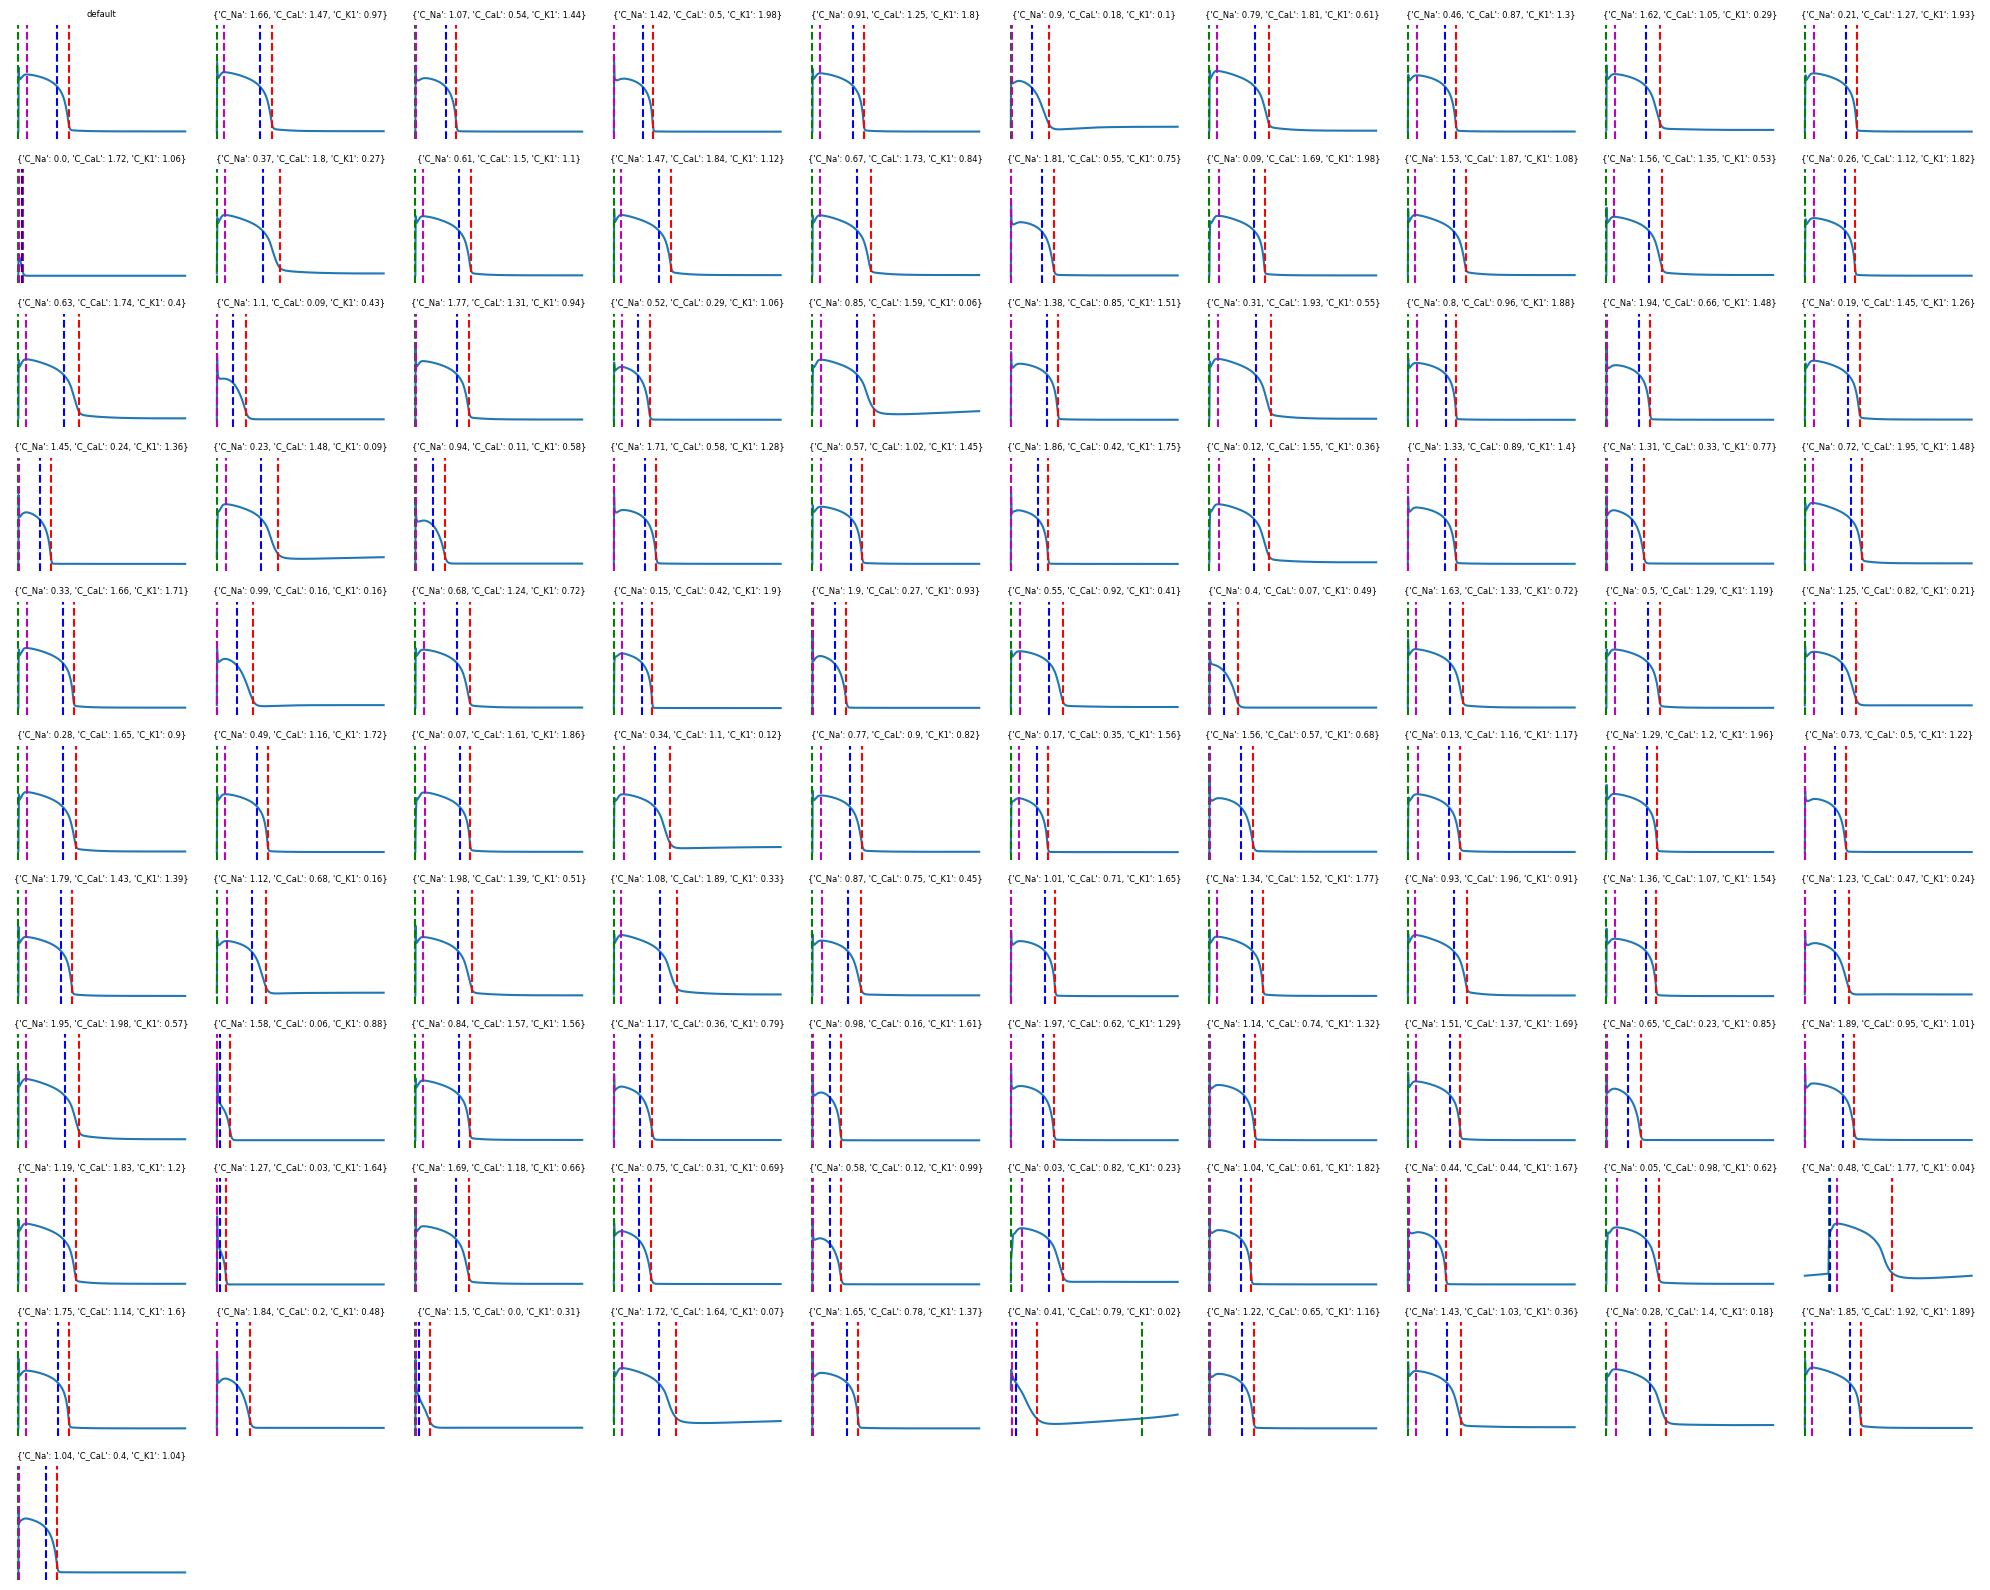

In [16]:
# 1. Create an 8x10 grid (100 slots for 100 plots)
fig, axs = plt.subplots(11, 10, figsize=(20, 16))

# Start the 'Na' key value
key_Na = -1
max_key = len(voltage.keys())
# 2. Flatten the grid to a single list for easy looping
# Enumerate over the 80 subplot axes in the flattened array
for i, ax in enumerate(axs.flat):
    
    # We only want to plot in the first 75 subplots
    if i < max_key:
        # Check if the data for the current key exists
        if key_Na in voltage:
            APs, starting_indexes = get_AP(voltage[key_Na])
            last_AP = APs[-1]
            ax.plot(last_AP)
            dvdt_max,plateau_duration, plateau_end_idx = get_dvdt_max_and_plateau_duration(last_AP, dt=0.2) # dt=0.2 ms\
            APD, APD_boundary = get_APD(last_AP, dt=0.2, APD_percentage=0.1)
            # plot apd boundary, plateau_end as vertical line
            ax.axvline(x=APD_boundary[0], color='g', linestyle='--', label='APD Start')
            ax.axvline(x=APD_boundary[1], color='r', linestyle='--', label='APD End')
            ax.axvline(x=plateau_end_idx, color='b', linestyle='--', label='Plateau End')
            # plot vertical line of 2nd maximum location
            # 2nd maximum has to be at least 10 points away right to first maximum
            # so it is the maximum of voltage[max_index+10:]
            first_max_idx = np.argmax(last_AP)
            second_max_idx = np.argmax(last_AP[first_max_idx+10:]) + first_max_idx + 10
            
            ax.axvline(x=second_max_idx, color='m', linestyle='--', label='2nd Maximum')
            
            ax.set_ylim(-100,120)
            # Set the title with the current Na value
            if key_Na == -1:
                ax.set_title(f"default", fontsize=6)
            else:
                ax.set_title(f"{parameters[key_Na]}", fontsize=6)
            key_Na += 1
            # Optional: Customize axes for line plots
            ax.set_xticks([]) # Remove x-ticks
            ax.set_yticks([]) # Remove y-ticks
        
        else:
            # Handle case where the expected data key is missing (optional)
            ax.text(0.5, 0.5, "Data Missing", transform=ax.transAxes, ha='center')
            
    # Always turn off the axis for all subplots for a clean look
    ax.axis('off')

# 3. Adjust layout and display
plt.tight_layout()
plt.savefig("TNNP_cell_para_Variation_last_AP.png", dpi=300)